<div style="display:block;width:100%;margin:auto;" direction=rtl align=center><br><br>
    <div  style="width:100%;margin:100;display:block;background-color:#fff0;"  display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">
            <tr>
                <td  style="border: none!important;">
        <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                <h1 align=center><font size=5 color="#87CEEB"> <b>Introduction to Cognitive Science</b><br><br>HomeWork #2</i></font></h1>
            </td>
            <td style="border: none!important;">
        <img width=170 align=left  src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
            </td>
        </tr>
        </table>
    
</div>
<br>
<font size=3 color="#00FFFF"> Sina Pirmoradian : 810101125 <br></font><br>

<font color="#FA5F55"><h1>HW #2 Part #4</h2></font>

<font color="#F4BB44"><h3>Connect Google Drive</h3></font>

In [1]:
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


<font color="#F4BB44"><h3>Import Reqiured Library</h3></font>

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score
from scipy.stats import sem
import numpy as np
import matplotlib.pyplot as plt

<font color="#F4BB44"><h3>Load the Data</h3></font>

In [3]:
# Load the time series data and labels from numpy files
data = np.load('/content/drive/MyDrive/Cognetive/HW_2/assignment2-face-data.npy')
labels = np.load('/content/drive/MyDrive/Cognetive/HW_2/assignment2-face-data-labels.npy')

<font color="#F4BB44"><h3>Moving Average through the Time</h3></font>

In [4]:
# Calculate firing rate using a moving average window of length 50
window_length = 50
str_ = 1

Moving_average = np.zeros((data.shape[0], data.shape[1], (data.shape[2] - window_length + 1)))
for i in range(data.shape[0]):
  for j in range(data.shape[1]):
    Moving_average[i,j] = np.convolve(data[i,j,:], np.ones(window_length)/window_length, mode='valid')[::str_]

<font color="#F4BB44"><h3>Part_1</h3></font>

---



<font color="#F4BB44"><h3>SVM Analysis</h3></font>

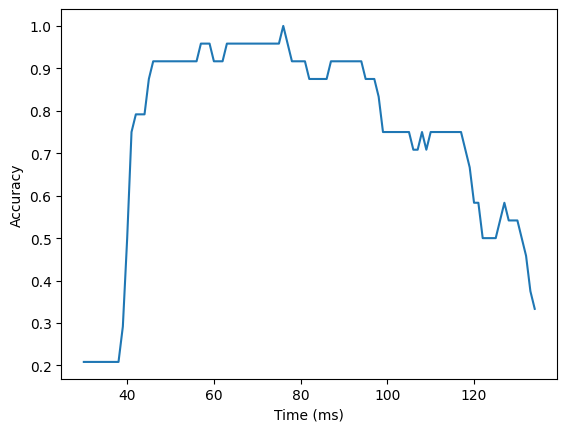

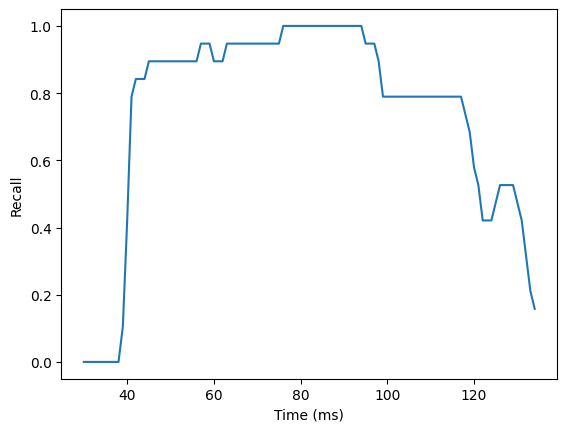

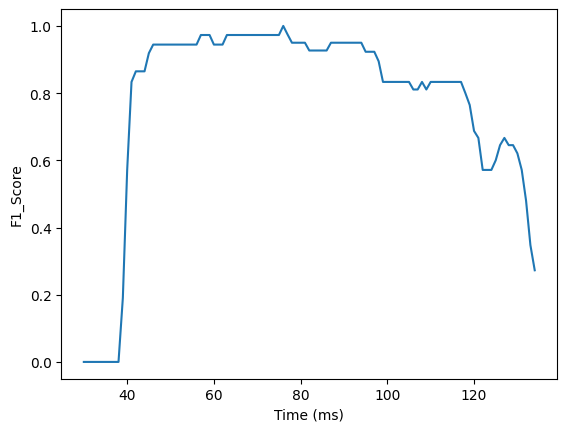

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, f1_score


import numpy as np
import matplotlib.pyplot as plt

# Load the time series data and labels from numpy files
labels = np.load('/content/drive/MyDrive/Cognetive/HW_2/assignment2-face-data-labels.npy')
# Calculate the number of windows
num_obs, num_neurons, num_samples = data.shape
window_size = 100
# Split the time series data into non-overlapping windows
num_windows = int(data.shape[2] / window_size)


stride = 5
accs = []
rec = []
f1 = []
for i in range(0, num_samples, stride):
    x = data[:,:, i:i+window_size].mean(axis=2)
    labels = labels.ravel()
    labels[:17]=0
    labels[17:]=1
    X_train, X_test, y_train, y_test = train_test_split(x, labels, test_size=0.3,random_state=15)
    class_weight = {0: 60/77, 1: 17/77}
    clf = SVC(class_weight=class_weight)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accs.append(accuracy_score(y_test, y_pred))
    rec.append(recall_score(y_test, y_pred))
    f1.append(f1_score(y_test, y_pred))

# Plot the accuracy as a function of time
plt.plot(np.arange(30, 135), accs[30:135])
plt.xlabel('Time (ms)')
plt.ylabel('Accuracy')
plt.show()

# Plot the accuracy as a function of time
plt.plot(np.arange(30, 135), rec[30:135])
plt.xlabel('Time (ms)')
plt.ylabel('Recall')
plt.show()

# Plot the accuracy as a function of time
plt.plot(np.arange(30, 135), f1[30:135])
plt.xlabel('Time (ms)')
plt.ylabel('F1_Score')
plt.show()



<font color="#F4BB44"><h3>Part_2</h3></font>

---



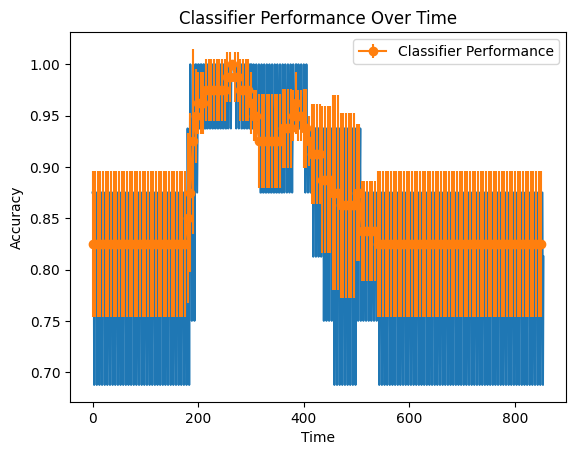

In [6]:
# Calculate the number of windows
num_obs, num_neurons, num_samples = Moving_average.shape
window_size = 100
# Split the time series data into non-overlapping windows
num_windows = int(data.shape[2] / window_size)
stride = 5
rns = 5
all_accuracies = []
rec = []
f1 = []
accs = np.zeros((int(num_samples/stride), rns))
for i in range(0, num_samples, stride):
    x = Moving_average[:,:, i:i+window_size].mean(axis=2)
    accuracy = []
    for j in range(rns):
      # labels = labels.ravel()
      labels[:17]=0
      labels[17:]=1
      X_train, X_test, y_train, y_test = train_test_split(x, labels, test_size=0.2, random_state = j)
      clf = SVC(random_state=j)
      clf.fit(X_train, y_train)
      y_pred = clf.predict(X_test)
      # Evaluate the classifier's accuracy
      accuracy = accuracy_score(y_test, y_pred)
      rec.append(recall_score(y_test, y_pred, average='weighted'))
      # rec.append(recall_score(y_test, y_pred))
      f1.append(f1_score(y_test, y_pred, average='weighted'))
      # f1.append(f1_score(y_test, y_pred))
      # Append the accuracies for the current random seed to the list of all accuracies
      all_accuracies.append(accuracy)

# Calculate the mean and confidence interval of the classifier performance over time
all_accuracies=np.array(all_accuracies)
all_accuracies=all_accuracies.reshape((171,rns))
# mean_accuracies = np.mean(all_accuracies, axis=0)
mean_accuracies = np.mean(all_accuracies, axis=1)

confidence_interval = sem(all_accuracies, axis=1) * 1.96  # 95% confidence interval
# Generate a time series plot of the classifier performance
time_points = np.arange(0,num_samples,rns)
# plt.plot(np.arange(0,900,5), mean_accuracies)
plt.plot(np.arange(0, 855), rec)
plt.errorbar(time_points, mean_accuracies, yerr=confidence_interval, fmt='-o', label='Classifier Performance')
plt.xlabel('Time')
plt.ylabel('Accuracy')
plt.title('Classifier Performance Over Time')
plt.legend()
plt.show()


<font color="#F4BB44"><h3>Part_3</h3></font>

---



<font color="#F4BB44"><h3>Analyze Time Feature</h3></font>

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, recall_score, f1_score
from scipy.stats import sem
import numpy as np
import matplotlib.pyplot as plt

# Load the data and labels from numpy files
data = np.load('/content/drive/MyDrive/Cognetive/HW_2/assignment2-face-data.npy')
labels = np.load('/content/drive/MyDrive/Cognetive/HW_2/assignment2-face-data-labels.npy')
labels = labels.ravel()

# Calculate the number of windows
num_obs, num_neurons, num_samples = data.shape
window_size = 100
# Split the data into non-overlapping windows
num_windows = int(data.shape[2] / window_size)

stride = 5
rns = 5
all_lda_accuracies = []
all_svm_accuracies = []
lda_accuracies = []
svm_accuracies = []
lda_rec = []
svm_rec = []
lda_f1 = []
svm_f1 = []
lda_timing = []
svm_timing = []
lda_onsets = []
lda_peaks = []
svm_onsets = []
svm_peaks = []
lda_result = []
svm_result =[]

for i in range(0, num_samples, stride):
    x = data[:,:, i:i+window_size].mean(axis=2)
    for j in range(rns):
        # Split the data into training and test sets
        X_train, X_test, y_train, y_test = train_test_split(x, labels, test_size=0.2, random_state=j)

        # Train the LDA classifier
        lda = LDA(n_components=2)
        X_train_lda = lda.fit_transform(X_train, y_train)
        X_test_lda = lda.transform(X_test)
        lda_clf = SVC(kernel='linear')
        lda_clf.fit(X_train_lda, y_train)
        lda_y_pred = lda_clf.predict(X_test_lda)
        all_lda_accuracies.append(accuracy_score(y_test, lda_y_pred))
        lda_rec.append(recall_score(y_test, lda_y_pred, average='weighted', zero_division=1))
        lda_f1.append(f1_score(y_test, lda_y_pred, average='weighted'))
        lda_timing.append(i)

        # Train the SVM classifier
        svm_clf = SVC(kernel='linear')
        svm_clf.fit(X_train, y_train)
        svm_y_pred = svm_clf.predict(X_test)
        all_svm_accuracies.append(accuracy_score(y_test, svm_y_pred))
        svm_rec.append(recall_score(y_test, svm_y_pred, average='weighted', zero_division=1))
        svm_f1.append(f1_score(y_test, svm_y_pred, average='weighted'))
        svm_timing.append(i)
        # Calculate the timing of onset and peak for the LDA classifier
        lda_activation = np.abs(lda.decision_function(X_test))
        lda_onset = np.argmax(lda_activation > np.mean(lda_activation) + np.std(lda_activation))
        lda_peak = np.argmax(lda_activation)
        lda_onsets.append(lda_onset)
        lda_peaks.append(lda_peak)
    
        # Calculate the timing of onset and peak for the SVM classifier
        svm_activation = np.abs(svm_clf.decision_function(X_test))
        svm_onset = np.argmax(svm_activation > np.mean(svm_activation) + np.std(svm_activation))
        svm_peak = np.argmax(svm_activation)
        svm_onsets.append(svm_onset)
        svm_peaks.append(svm_peak)

    svm_result = np.array([all_svm_accuracies, svm_f1, svm_rec])
    lda_result = np.array([all_lda_accuracies, lda_f1, lda_rec])

# Calculate the mean and confidence interval of the classifier performance over time
lda_mean_acc = np.mean(all_lda_accuracies)
conf_interval_lda = sem(all_lda_accuracies) * 1.96
svm_mean_acc = np.mean(all_svm_accuracies)
conf_interval_svm = sem(all_svm_accuracies) * 1.96

<font color="#F4BB44"><h3>Compare LDA and SVM on classifier performance over the time</h3></font>

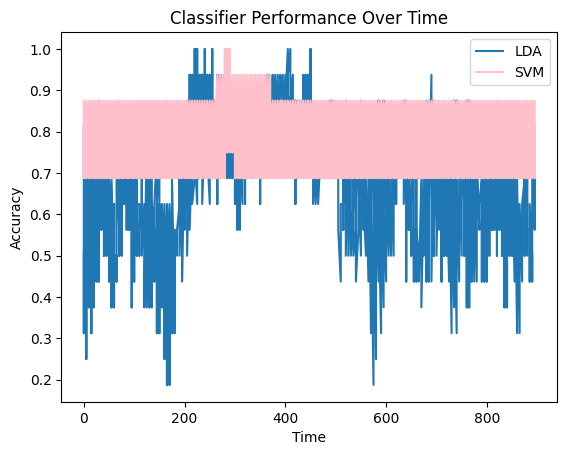

In [9]:
# Generate a time series plot of the classifier performance
plt.plot(lda_timing, all_lda_accuracies, label='LDA')
plt.plot(svm_timing, all_svm_accuracies, label='SVM', color = 'pink')
plt.xlabel('Time')
plt.ylabel('Accuracy')
plt.title('Classifier Performance Over Time')
plt.legend()
plt.show()


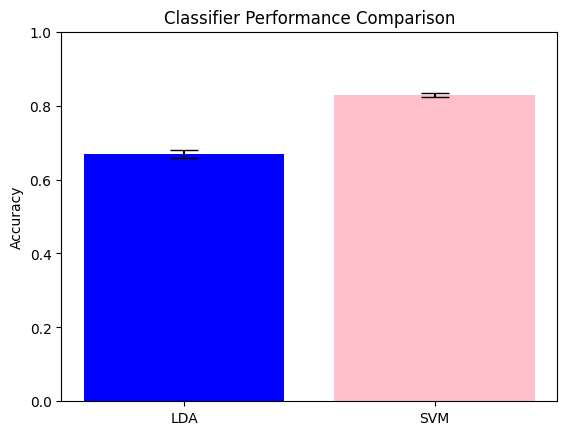

In [10]:
#Generate a bar plot of the mean accuracy and confidence interval of each classifier
plt.bar(['LDA', 'SVM'], [lda_mean_acc, svm_mean_acc], yerr=[conf_interval_lda, conf_interval_svm], capsize=10, color = ['blue','pink'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Classifier Performance Comparison')
plt.show()

<font color="#F4BB44"><h3>Compare LDA and SVM over timing of onset and peak</h3></font>

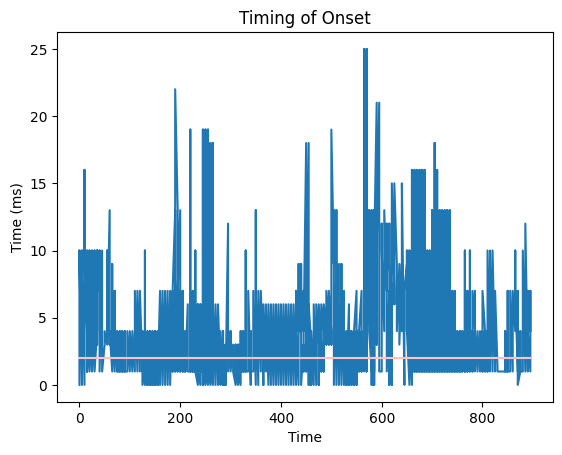

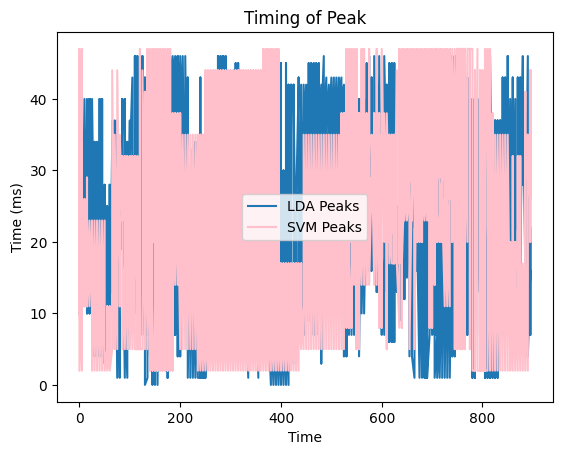

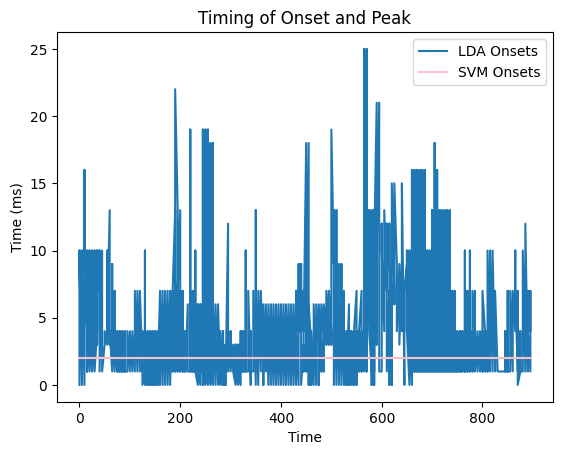

In [11]:
#Generate a time series plot of the timing of onset and peak for each classifier
plt.plot(lda_timing, lda_onsets, label='LDA Onsets')
plt.plot(lda_timing, svm_onsets, label='SVM Onsets', color = 'pink')
plt.xlabel('Time')
plt.ylabel('Time (ms)')
plt.title('Timing of Onset')
plt.show()

plt.plot(lda_timing, lda_peaks, label='LDA Peaks')
plt.plot(lda_timing, svm_peaks, label='SVM Peaks', color = 'pink')
plt.xlabel('Time')
plt.ylabel('Time (ms)')
plt.title('Timing of Peak')
plt.legend()
plt.show()

plt.plot(lda_timing, lda_onsets, label='LDA Onsets')
plt.plot(lda_timing, svm_onsets, label='SVM Onsets', color = 'pink')
plt.xlabel('Time')
plt.ylabel('Time (ms)')
plt.title('Timing of Onset and Peak')
plt.legend()
plt.show()

<font color="#F4BB44"><h3>Compare LDA and SVM over metrics</h3></font>

In [12]:
svm_data = svm_result.mean(axis=1), svm_result.std(axis=1)
lda_data = lda_result.mean(axis=1), lda_result.std(axis=1)

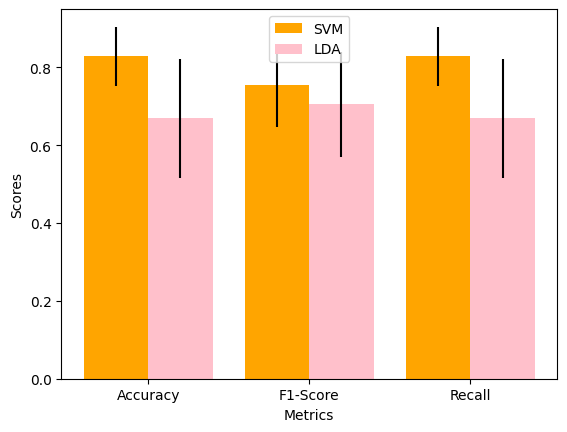

In [13]:
width = 0.4
x = np.arange(len(svm_data[0]))
plt.bar(x-0.2 , svm_data[0], width, color='orange', yerr=svm_data[1])
plt.bar(x+0.2, lda_data[0], width, color='pink', yerr=lda_data[1])
plt.xticks(x, ['Accuracy', 'F1-Score', 'Recall'])
plt.xlabel("Metrics")
plt.ylabel("Scores")
plt.legend(["SVM", "LDA"])
plt.show()